# LangGraph Lab 2

In [1]:
# import neccessary libraries 
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
import openai
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [2]:
# load env
load_dotenv(override=True)

True

In [3]:
# import usefull function from langchain community
from langchain_community.utilities import GoogleSerperAPIWrapper

serper=GoogleSerperAPIWrapper()

serper.run("What is the current day")

'Friday, May 15, 2026'

In [4]:
# call langchain wraper tool to convert function into tool
from langchain_core.tools import Tool
tool_search = Tool(
    name="search",
    func=serper.run,
    description="online search tool"
)

In [5]:
# try the search tool
tool_search.invoke("what is today")

'Friday, May 15, 2026'

* ^ Great: above is simply how can change function into tool in langchain/langgraph

In [6]:
# lets create our on tool now
pushover_token=os.getenv("PUSHOVER_TOKEN")
pushover_user=os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send an email push notification to the customer"""
    requests.post(pushover_url, data={"token":pushover_token, "user":pushover_user, "message":text})

# convert the function into tool
tool_push = Tool(
    name="push",
    func=push,
    description="Email notification pusher tool"
)

# try push tool
tool_push.invoke("Hello, me")

### Back to the Graph

Using TypedDict instead of BaseModel for the State object

When we implement tools, we always need to make 2 changes to the code:

1. Changes to provide the tools to OpenAI in json when we make the call

2. Changes to handle the results back: look for the model staying that the finish_reason=="tool_calls" and then retrieve the call, run the function, provide the results.

In [7]:
# bring our tools 
tools = [tool_search, tool_push]

### Let's follow our lovely step to build a graph

In [8]:
# step 1: define the state object
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [9]:
# step 2: start a graph builder with this state class
graph_builder = StateGraph(State)

In [10]:
# call brain of our agents
llm =  ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [11]:
# step 3: create a node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [12]:
# step 4: create edge
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot") # whenever tools called it has to be return into chatbot to decide what is next

# add start node
graph_builder.add_edge(START, "chatbot")

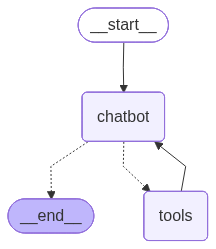

In [13]:
# step 5: complie the graph

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# Show time: let's cook it

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content

# call gradio
gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Let's add memory

### BUT WAIT!

We have this whole Graph maintaining the state and appending to the state.

Why isn't this handling memory?

### This is a crucial point for understanding LangGraph

> A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.


One "Super-Step" of the graph represents one invocation of passing messages between agents.

In idomatic LangGraph, you call invoke to run your graph for each super-step; for each interaction.

The reducer handles state updates automatically within one super-step, but not between them.

That is what checkpointing achieves.

In [15]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

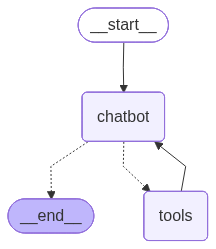

In [16]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [18]:
graph.get_state(config)

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [19]:
list(graph.get_state_history(config))

[]

## SQL Storage in LangGraph

In [21]:
import sqlite3

from langgraph.checkpoint.sqlite import SqliteSaver
db_path = "memory/memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

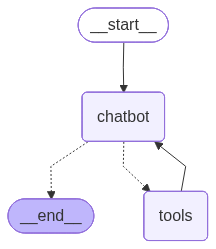

In [22]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [ ]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Hello, Liul is here', additional_kwargs={}, response_metadata={}, id='23a89710-340a-436a-963b-9baaa0eb2535')]}
{'messages': [HumanMessage(content='Hello, Liul is here', additional_kwargs={}, response_metadata={}, id='23a89710-340a-436a-963b-9baaa0eb2535'), AIMessage(content='Hello Liul! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 79, 'total_tokens': 91, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_787f083501', 'id': 'chatcmpl-Dfv9pwsB3Qjyxk0y2Qhuvsk9uW6N2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2db8-7fe8-7d32-9921-8a3ca352a9bc-0', tool_calls=[], invalid_